# Looking into Wrapped Normal Distribution on unit hypersphere

# Wraped Normal Distribution on Hypersphere PDF details:

Let $X \in S^{d-1} \subset \mathbb{R}^d$, where $S^{d-1}$ is the unit hypersphere. A wrapped normal distribution on $S^{d-1}$ is centered at a mean direction

$$ \mu \in S^{d-1},$$

with spread controlled by $\sigma > 0.$

To sample from it, we first draw normally in the tangent space at $\mu,$

$$ V \sim N(0, \sigma^2 I),$$

and then wrap $V$ onto the sphere using the exponential map:

$$ X = \exp_\mu(V).$$

For a point $x \in S^{d-1}$, let

$$\theta = \arccos(\mu^\top x)$$

be the geodesic angle between $x$ and the mean direction $\mu$.

A useful approximation to the wrapped normal density is

$$ f_X(x) \approx
(2\pi\sigma^2)^{-\frac{m}{2}}
\exp\left(-\frac{\theta^2}{2\sigma^2}\right)
\left(\frac{\theta}{\sin \theta}\right)^{m-1}$$

where $m = d - 1$ is the intrinsic dimension of the hypershphere.

Small $\sigma$ gives a tight cluster near $\mu$, while larger $\sigma$ spreads points farther around the sphere.


We can also use the exact pdf and truncate its sum:

$$ f_X(x) = 
\sum_{k = -\infty}^{\infty}
(2\pi\sigma^2)^{-\frac{m}{2}}
\exp\left(
-\frac{(\theta + 2\pi k)^2}{2\sigma^2}
\right)
\left|
\frac{\theta + 2\pi k}{\sin\theta}
\right|^{m-1}$$

and sum across some finite $\{-K, -K + 1, \dots,K - 1, K\}.$



In [14]:
import importlib
import ecc_vr as vr

importlib.reload(vr)

<module 'ecc_vr' from '/Users/josephmatatyaou/Desktop/Euler REU/STA199REU/Package/ecc_vr/__init__.py'>

In [15]:
import numpy as np

def sample_wrapped_normal_hypersphere(
    n_points,
    dim,
    sigma = 1,
    mean_direction = None,
    seed = None
):

    """
    Sample points on the unit hypersphere S^{dim-1} in R^dim
    using an isotropic wrapped normal distribution.

    sigma is the tangent-space standard deviation, in radians.

    """

    rng = np.random.default_rng(seed)

    if mean_direction is None:
        mu = np.zeros(dim)
        mu[0] = 1
    else:
        mu = np.asarray(mean_direction, dtype = float)
        if mu.shape != (dim,):
            raise ValueError
        mu = mu / np.linalg.norm(mu)
    
    Z = rng.normal(0.0, sigma, size = (n_points, dim))

    # project normal noise onto tangent space at mu

    V = Z - (Z @ mu)[:, None] * mu[None, :]
    r = np.linalg.norm(V, axis =1, keepdims=True)

    U = np.zeros_like(V)
    nonzero = r[:, 0] > 0
    U[nonzero] = V[nonzero] / r[nonzero]

    #exponential map on unit sphere
    X = np.cos(r) * mu[None, :] + np.sin(r) * U 

    # floating point drift
    X = X / np.linalg.norm(X, axis = 1, keepdims = True)

    return X

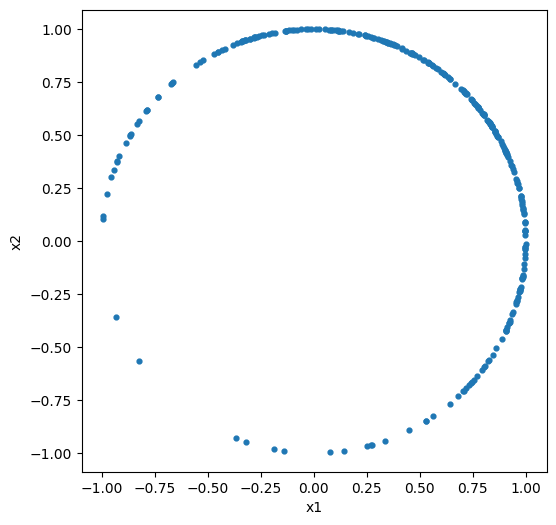

In [16]:
import matplotlib.pyplot as plt

X = sample_wrapped_normal_hypersphere(
    n_points=300,
    dim=2,
    sigma=1,
    mean_direction= [1,1],
    seed=None,
)


plt.figure(figsize = (6,6))
plt.scatter(X[:, 0], X[:,1], s =12)
plt.axis("equal")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

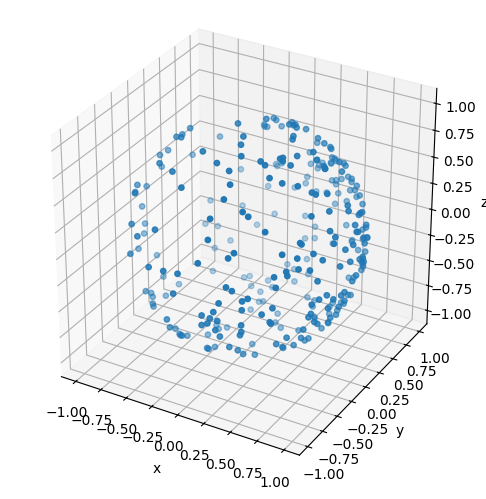

In [17]:
X2 = sample_wrapped_normal_hypersphere(
    n_points=300,
    dim=3,
    sigma=1,
    mean_direction= [1,0,0],
    seed=None,
)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X2[:, 0], X2[:,1],X2[:, 2], s =15)
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")

ax.set_box_aspect([1, 1, 1])
plt.show()


In [18]:
import ecc_vr as vr

def wrapped_normal_hypersphere_pdf_approx(X, sigma = 0.35, mean_direction = None):
    n_points, d = X.shape
    m = d - 1

    if mean_direction is None:
        mu = np.zeros(d)
        mu[0] = 1.0
    else:
        mu = np.asarray(mean_direction, dtype = float)

    mu = mu / np.linalg.norm(mu)

    #normalize X
    X_unit = X / np.linalg.norm(X, axis = 1, keepdims=True)

    dots = X_unit @ mu
    dots = np.clip(dots, -1.0, 1.0)

    theta = np.arccos(dots)
    const = (2.0 * np.pi * sigma**2) ** (-m / 2.0)
    guassian_part = np.exp(-(theta**2) / (2.0 * sigma**2))

    ratio = np.ones_like(theta)
    mask = theta > 1e-10
    ratio[mask] = theta[mask] / np.sin(theta[mask])

    curvature_part = ratio ** (m - 1)

    return const * guassian_part * curvature_part

def wrapped_normal_hypersphere_pdf_exact(
    X,
    sigma=0.35,
    mean_direction=None,
    K=5,
    eps=1e-12,
):
    n_points, d = X.shape
    m = d - 1

    if mean_direction is None:
        mu = np.zeros(d)
        mu[0] = 1.0
    else:
        mu = np.asarray(mean_direction, dtype=float)

    mu = mu / np.linalg.norm(mu)

    X_unit = X / np.linalg.norm(X, axis=1, keepdims=True)

    dots = X_unit @ mu
    dots = np.clip(dots, -1.0, 1.0)

    theta = np.arccos(dots)
    sin_theta = np.sin(theta)

    const = (2.0 * np.pi * sigma**2) ** (-m / 2.0)

    f = np.zeros(n_points, dtype=float)

    for k in range(-K, K + 1):
        r = theta + 2.0 * np.pi * k

        gaussian_part = np.exp(-(r**2) / (2.0 * sigma**2))

        jacobian_part = np.ones_like(theta)
        mask = sin_theta > eps
        jacobian_part[mask] = np.abs(r[mask] / sin_theta[mask]) ** (m - 1)

        # At theta = 0, use limiting value for the k = 0 term.
        if k == 0:
            jacobian_part[~mask] = 1.0

        f += const * gaussian_part * jacobian_part

    return f

def weighted_distance_matrix_wrapped_normal_pdf(X, sigma = 0.35, mean_direction = None):
    
    D = vr.pairwise_dist(X)
    f = wrapped_normal_hypersphere_pdf_exact(
        X,
        sigma = sigma,
        mean_direction=mean_direction,
        K = 20
    )

    _, d = X.shape
    m = d - 1


    f = np.maximum(f, 1e-12)   # guard against zero density
    f = f / f.mean()
    s = f ** (1.0 / m)   # (n,)

    si = s[:, None]
    sj = s[None, :]

    scale = (2.0 * si * sj) / (si + sj)

    D_w = D * scale
    np.fill_diagonal(D_w, 0.0)
    return D_w, scale

In [19]:

def edge_count_sim(
    n_points,
    t: float,
    n_resamples: int,
    d: int,
    sigma: float,
    mean_direction=None,
    seed: int | None = None,
) -> np.ndarray:
    
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        X = sample_wrapped_normal_hypersphere(
        n_points,
        d,
        sigma = sigma,
        mean_direction = mean_direction,
        seed = sample_seed
        )

        edge_counts[i] = vr.count_edges(X, t=t)

    return edge_counts

def edge_count_sim_kde(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    sigma: float,
    h: float,
    mean_direction=None,
    seed: int | None = None,
) -> np.ndarray:

    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        X = sample_wrapped_normal_hypersphere(
        n_points,
        d,
        sigma = sigma,
        mean_direction = mean_direction,
        seed = sample_seed
        )

        Dw, _ = vr.weighted_distance_matrix_kde(
            X,
            h=h,
            d_manifold= d - 1,
        )

        edge_counts[i] = vr.count_edges(X, t=t, D=Dw)

    return edge_counts

def edge_count_sim_pdf(
    n_points: int,
    t: float,
    n_resamples: int,
    d: int,
    sigma: float,
    mean_direction=None,
    seed: int | None = None,
) -> np.ndarray:
    
    rng = np.random.default_rng(seed)
    edge_counts = np.empty(n_resamples, dtype=int)

    for i in range(n_resamples):
        sample_seed = int(rng.integers(0, 1_000_000_000))

        X = sample_wrapped_normal_hypersphere(
        n_points,
        d,
        sigma = sigma,
        mean_direction = mean_direction,
        seed = sample_seed
        )

        Dw, _ = weighted_distance_matrix_wrapped_normal_pdf(
            X,
            sigma = sigma,
            mean_direction = mean_direction
        )

        edge_counts[i] = vr.count_edges(X, t=t, D=Dw)

    return edge_counts

In [21]:
import ecc_vr as vr
from ecc_vr.metrics import count_edges

vr.count_edges = count_edges

def summarize_counts(label, counts):
    mean = counts.mean()
    sd = counts.std(ddof=1)
    q025, q50, q975 = np.quantile(counts, [0.025, 0.5, 0.975])

    print(
        f"{label:>8} | mean = {mean:.2f} | sd = {sd:.2f} | "
        f"median = {q50:.2f} | 95% interval = [{q025:.2f}, {q975:.2f}]"
    )


for n_points in [50, 100, 250]:
    print(f"\nn_points = {n_points}")

    edge_counts_raw = edge_count_sim(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        sigma=1,
        mean_direction=[1, 0, 0],
        seed=None,
    )

    edge_counts_kde = edge_count_sim_kde(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        sigma = 1,
        h=0.15,
        mean_direction=[1, 0, 0],
        seed=None,
    )

    edge_counts_pdf = edge_count_sim_pdf(
        n_points=n_points,
        t=1,
        n_resamples=500,
        d=3,
        sigma = 1,
        mean_direction = [1, 0, 0],
        seed=None,
    )

    summarize_counts("raw", edge_counts_raw)
    summarize_counts("kde", edge_counts_kde)
    summarize_counts("pdf", edge_counts_pdf)


n_points = 50
     raw | mean = 7.67 | sd = 2.90 | median = 7.00 | 95% interval = [3.00, 13.52]
     kde | mean = 5.62 | sd = 2.54 | median = 5.00 | 95% interval = [1.00, 11.00]
     pdf | mean = 7.56 | sd = 2.91 | median = 7.00 | 95% interval = [3.00, 13.00]

n_points = 100
     raw | mean = 15.50 | sd = 4.08 | median = 15.00 | 95% interval = [9.00, 25.00]
     kde | mean = 11.56 | sd = 3.38 | median = 12.00 | 95% interval = [6.00, 18.00]
     pdf | mean = 15.52 | sd = 4.38 | median = 15.00 | 95% interval = [8.00, 24.00]

n_points = 250
     raw | mean = 38.83 | sd = 6.70 | median = 39.00 | 95% interval = [27.00, 54.00]
     kde | mean = 32.69 | sd = 6.41 | median = 32.00 | 95% interval = [21.00, 46.00]
     pdf | mean = 39.83 | sd = 9.21 | median = 39.00 | 95% interval = [27.00, 54.52]


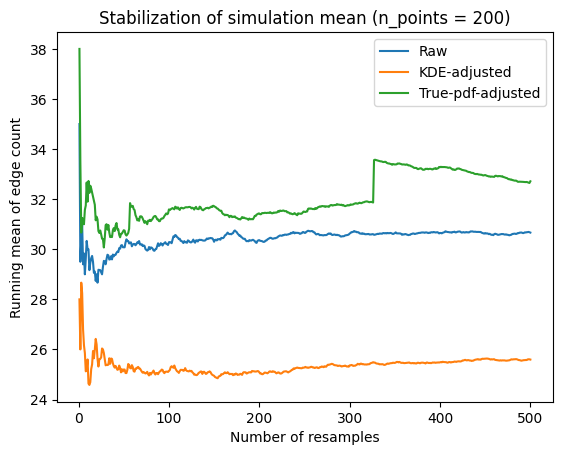

In [22]:
# running mean comparison for one fixed n_points
n_points = 200
n_resamples = 500

edge_counts_raw = edge_count_sim(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    sigma=1,
    mean_direction=[1, 0, 0],
    seed=None,
)

edge_counts_kde = edge_count_sim_kde(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    sigma=1,
    h=0.15,
    mean_direction=[1, 0, 0],
    seed=None,
)

edge_counts_pdf = edge_count_sim_pdf(
    n_points=n_points,
    t=1,
    n_resamples=n_resamples,
    d=3,
    sigma = 1,
    mean_direction=[1, 0, 0],
    seed=None,
)

k = np.arange(1, n_resamples + 1)

running_mean_raw = np.cumsum(edge_counts_raw) / k
running_mean_kde = np.cumsum(edge_counts_kde) / k
running_mean_pdf = np.cumsum(edge_counts_pdf) / k

plt.plot(k, running_mean_raw, label="Raw")
plt.plot(k, running_mean_kde, label="KDE-adjusted")
plt.plot(k, running_mean_pdf, label="True-pdf-adjusted")
plt.xlabel("Number of resamples")
plt.ylabel("Running mean of edge count")
plt.title("Stabilization of simulation mean (n_points = 200)")
plt.legend()
plt.show()

Normal QQ Plot Raw: Shapiro-Wilk p-value = 0.09846


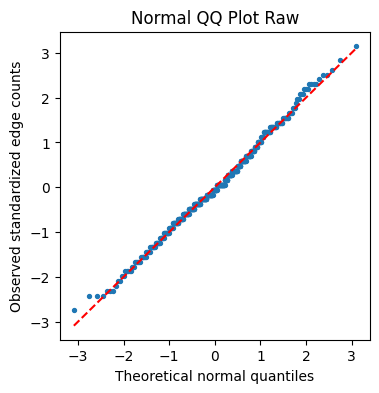

Normal QQ Plot KDE: Shapiro-Wilk p-value = 0.01002


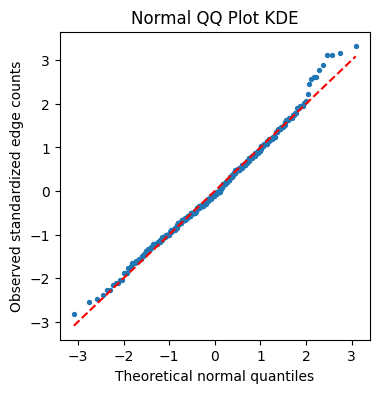

Normal QQ Plot PDF: Shapiro-Wilk p-value = 4.346e-11


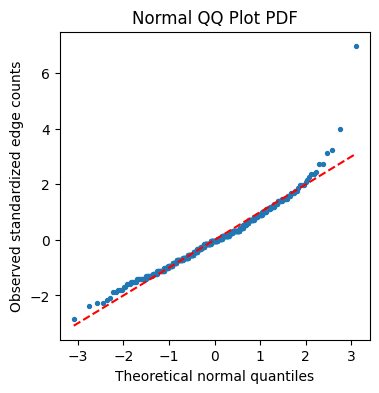

In [ ]:
from scipy.stats import shapiro
from statistics import NormalDist

def normal_qq_plot(counts, title):
    mu = counts.mean()
    sd = counts.std(ddof=1)

    if sd == 0:
        raise ValueError("All edge counts are identical, so standardized QQ plot is undefined.")

    z = np.sort((counts - mu) / sd)

    p_vals = (np.arange(1, len(z) + 1) - 0.5) / len(z)
    q = np.array([NormalDist().inv_cdf(pi) for pi in p_vals])

    stat, p = shapiro(counts)
    print(f"{title}: Shapiro-Wilk p-value = {p:.4g}")

    plt.figure(figsize=(4, 4))
    plt.scatter(q, z, s=8)
    plt.plot([q.min(), q.max()], [q.min(), q.max()], "r--")
    plt.xlabel("Theoretical normal quantiles")
    plt.ylabel("Observed standardized edge counts")
    plt.title(title)
    plt.show()



counts_raw = edge_count_sim(
    n_points=500,
    t=1,
    n_resamples=500,
    d=3,
    sigma=1,
    mean_direction=[1, 0, 0],
    seed=None,
)

normal_qq_plot(counts_raw, "Normal QQ Plot Raw")


counts_kde = edge_count_sim_kde(
    n_points=500,
    t=1,
    n_resamples=500,
    d=3,
    sigma=1,
    h=0.15,
    mean_direction=[1, 0, 0],
    seed=None,
)

normal_qq_plot(counts_kde, "Normal QQ Plot KDE")


counts_pdf = edge_count_sim_pdf(
    n_points=500,
    t=1,
    n_resamples=500,
    d=3,
    sigma=1,
    mean_direction=[1, 0, 0],
    seed=None,
)

normal_qq_plot(counts_pdf, "Normal QQ Plot PDF")